# MEIN DATASET (Working) 

Kurzer Überblick: Verteilungen und Längen der generierten E-Mails.

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")
df = pd.read_csv("synthetic_test_emails.csv")
df.head()

,id,damage_type,mood,info_level,accepted,char_count,issues
0,EMAIL_GEN_001,Wasserschaden,ruhig und strukturiert,vollständig,True,1107,NaN
1,EMAIL_GEN_002,Wasserschaden,ruhig und strukturiert,teilweise,True,776,NaN
2,EMAIL_GEN_003,Wasserschaden,ruhig und strukturiert,minimal,True,525,NaN
3,EMAIL_GEN_004,Wasserschaden,ruhig und strukturiert,vage,True,830,NaN
4,EMAIL_GEN_005,Wasserschaden,gestresst und panisch,vollständig,True,887,NaN


In [40]:
summary = {
    "total": len(df),
    "accepted": int(df["accepted"].sum()),
    "rejected": int((~df["accepted"]).sum()),
    "char_count_min": int(df["char_count"].min()),
    "char_count_median": float(df["char_count"].median()),
    "char_count_max": int(df["char_count"].max()),
}
summary

{'total': 100,
 'accepted': 100,
 'rejected': 0,
 'char_count_min': 359,
 'char_count_median': 830.0,
 'char_count_max': 1313}

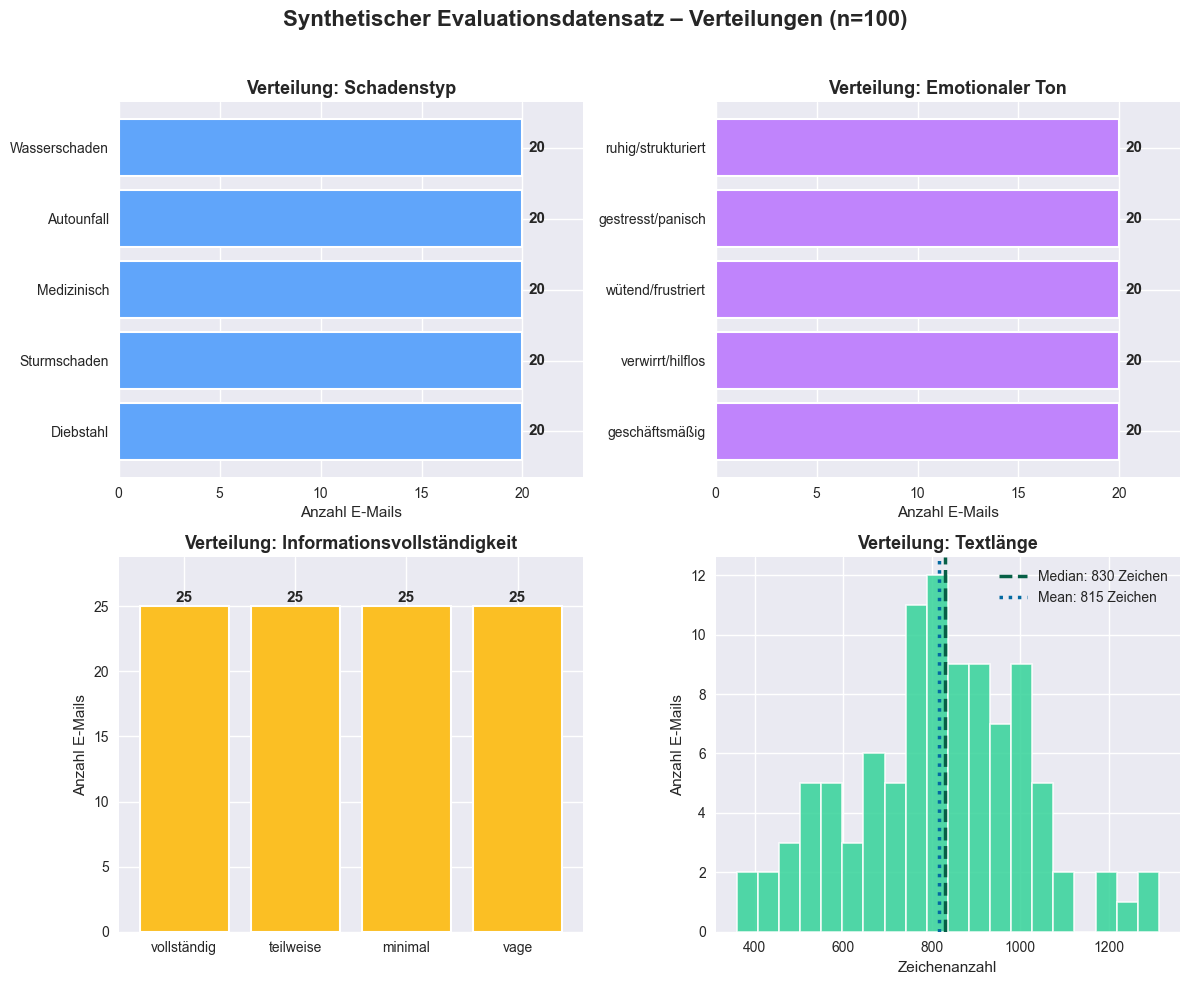


📊 Datensatz-Statistik:
   Gesamt: 100 E-Mails
   Textlänge: 359–1313 Zeichen (Median: 830)
   Generiert mit: GPT-5.2


In [45]:
# Datensatz-Verteilungen: 2x2 Übersicht
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Farbpalette
colors = {
    "damage": "#60a5fa",
    "mood": "#c084fc", 
    "info": "#fbbf24",
    "length": "#34d399"
}

# 1. Schadenstyp (oben links)
ax1 = axes[0, 0]
damage_order = ["Wasserschaden", "Autounfall", "Medizinisch", "Sturmschaden", "Diebstahl"]
damage_counts = df["damage_type"].value_counts().reindex(damage_order)
bars1 = ax1.barh(damage_counts.index, damage_counts.values, color=colors["damage"], edgecolor="white", linewidth=1.5)
ax1.set_xlabel("Anzahl E-Mails", fontsize=11)
ax1.set_title("Verteilung: Schadenstyp", fontsize=13, fontweight="bold")
for bar, val in zip(bars1, damage_counts.values):
    ax1.text(val + 0.3, bar.get_y() + bar.get_height()/2, f'{int(val)}', va='center', fontsize=11, fontweight="bold")
ax1.set_xlim(0, max(damage_counts) * 1.15)
ax1.spines[['top', 'right']].set_visible(False)
ax1.invert_yaxis()

# 2. Emotionaler Ton (oben rechts)
ax2 = axes[0, 1]
mood_order = ["ruhig und strukturiert", "gestresst und panisch", "wütend und frustriert", "verwirrt und hilflos", "geschäftsmäßig"]
mood_counts = df["mood"].value_counts().reindex(mood_order)
mood_labels = ["ruhig/strukturiert", "gestresst/panisch", "wütend/frustriert", "verwirrt/hilflos", "geschäftsmäßig"]
bars2 = ax2.barh(mood_labels, mood_counts.values, color=colors["mood"], edgecolor="white", linewidth=1.5)
ax2.set_xlabel("Anzahl E-Mails", fontsize=11)
ax2.set_title("Verteilung: Emotionaler Ton", fontsize=13, fontweight="bold")
for bar, val in zip(bars2, mood_counts.values):
    ax2.text(val + 0.3, bar.get_y() + bar.get_height()/2, f'{int(val)}', va='center', fontsize=11, fontweight="bold")
ax2.set_xlim(0, max(mood_counts) * 1.15)
ax2.spines[['top', 'right']].set_visible(False)
ax2.invert_yaxis()

# 3. Informationsvollständigkeit (unten links)
ax3 = axes[1, 0]
info_order = ["vollständig", "teilweise", "minimal", "vage"]
info_counts = df["info_level"].value_counts().reindex(info_order)
bars3 = ax3.bar(info_order, info_counts.values, color=colors["info"], edgecolor="white", linewidth=1.5)
ax3.set_ylabel("Anzahl E-Mails", fontsize=11)
ax3.set_title("Verteilung: Informationsvollständigkeit", fontsize=13, fontweight="bold")
for bar in bars3:
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, 
             f'{int(bar.get_height())}', ha='center', fontsize=11, fontweight="bold")
ax3.set_ylim(0, max(info_counts) * 1.15)
ax3.spines[['top', 'right']].set_visible(False)

# 4. Textlängenverteilung (unten rechts)
ax4 = axes[1, 1]
ax4.hist(df["char_count"], bins=20, color=colors["length"], edgecolor="white", linewidth=1.2, alpha=0.85)
ax4.axvline(df["char_count"].median(), color="#065f46", linestyle="--", linewidth=2.5, 
            label=f'Median: {int(df["char_count"].median())} Zeichen')
ax4.axvline(df["char_count"].mean(), color="#0369a1", linestyle=":", linewidth=2.5, 
            label=f'Mean: {int(df["char_count"].mean())} Zeichen')
ax4.set_xlabel("Zeichenanzahl", fontsize=11)
ax4.set_ylabel("Anzahl E-Mails", fontsize=11)
ax4.set_title("Verteilung: Textlänge", fontsize=13, fontweight="bold")
ax4.legend(loc="upper right", fontsize=10)
ax4.spines[['top', 'right']].set_visible(False)

# Haupttitel + Layout
fig.suptitle(f"Synthetischer Evaluationsdatensatz – Verteilungen (n={len(df)})", fontsize=16, fontweight="bold", y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("dataset_distributions.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

# Statistik ausgeben
print(f"\n📊 Datensatz-Statistik:")
print(f"   Gesamt: {len(df)} E-Mails")
print(f"   Textlänge: {int(df['char_count'].min())}–{int(df['char_count'].max())} Zeichen (Median: {int(df['char_count'].median())})")
print(f"   Generiert mit: GPT-5.2")

In [ ]:
# Erweiterte Analyse: Textlänge nach Variationsdimensionen
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# Farbpaletten
damage_colors = ["#3b82f6", "#60a5fa", "#93c5fd", "#bfdbfe", "#dbeafe"]
mood_colors = ["#a855f7", "#c084fc", "#d8b4fe", "#e9d5ff", "#f3e8ff"]
info_colors = ["#f59e0b", "#fbbf24", "#fcd34d", "#fde68a"]

# 1. Boxplot: Textlänge nach Schadenstyp
ax1 = axes[0, 0]
damage_order = ["Wasserschaden", "Autounfall", "Medizinisch", "Sturmschaden", "Diebstahl"]
data_by_damage = [df[df["damage_type"] == dt]["char_count"].values for dt in damage_order]
bp1 = ax1.boxplot(data_by_damage, labels=damage_order, patch_artist=True, vert=True)
for patch, color in zip(bp1["boxes"], damage_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax1.set_ylabel("Zeichenanzahl", fontsize=11)
ax1.set_title("Textlänge nach Schadenstyp", fontsize=13, fontweight="bold")
ax1.tick_params(axis='x', rotation=30)
ax1.spines[['top', 'right']].set_visible(False)
ax1.grid(axis='y', alpha=0.3)
# Mediane annotieren
for i, data in enumerate(data_by_damage):
    median = np.median(data)
    ax1.text(i+1, median + 30, f'{int(median)}', ha='center', fontsize=9, fontweight='bold', color='#1e40af')

# 2. Boxplot: Textlänge nach Stimmung
ax2 = axes[0, 1]
mood_order = ["ruhig und strukturiert", "gestresst und panisch", "wütend und frustriert", "verwirrt und hilflos", "geschäftsmäßig"]
mood_labels_short = ["ruhig", "gestresst", "wütend", "verwirrt", "geschäftlich"]
data_by_mood = [df[df["mood"] == m]["char_count"].values for m in mood_order]
bp2 = ax2.boxplot(data_by_mood, labels=mood_labels_short, patch_artist=True, vert=True)
for patch, color in zip(bp2["boxes"], mood_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax2.set_ylabel("Zeichenanzahl", fontsize=11)
ax2.set_title("Textlänge nach Emotionalem Ton", fontsize=13, fontweight="bold")
ax2.tick_params(axis='x', rotation=30)
ax2.spines[['top', 'right']].set_visible(False)
ax2.grid(axis='y', alpha=0.3)
for i, data in enumerate(data_by_mood):
    median = np.median(data)
    ax2.text(i+1, median + 30, f'{int(median)}', ha='center', fontsize=9, fontweight='bold', color='#6b21a8')

# 3. Boxplot: Textlänge nach Info-Level (WICHTIG - zeigt Einfluss von Vollständigkeit)
ax3 = axes[1, 0]
info_order = ["vollständig", "teilweise", "minimal", "vage"]
data_by_info = [df[df["info_level"] == il]["char_count"].values for il in info_order]
bp3 = ax3.boxplot(data_by_info, labels=info_order, patch_artist=True, vert=True)
for patch, color in zip(bp3["boxes"], info_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax3.set_ylabel("Zeichenanzahl", fontsize=11)
ax3.set_title("Textlänge nach Informationsvollständigkeit", fontsize=13, fontweight="bold")
ax3.spines[['top', 'right']].set_visible(False)
ax3.grid(axis='y', alpha=0.3)
# Mediane und Trend zeigen
medians_info = [np.median(d) for d in data_by_info]
for i, (data, median) in enumerate(zip(data_by_info, medians_info)):
    ax3.text(i+1, median + 30, f'{int(median)}', ha='center', fontsize=10, fontweight='bold', color='#b45309')
# Trendlinie
ax3.plot(range(1, 5), medians_info, 'r--', linewidth=2, alpha=0.7, label='Trend')
ax3.legend(loc='upper right')

# 4. Heatmap: Durchschnittliche Textlänge pro Kombination
ax4 = axes[1, 1]
pivot_mean = df.groupby(["damage_type", "info_level"])["char_count"].mean().unstack()
pivot_mean = pivot_mean.reindex(index=damage_order, columns=info_order)
im = ax4.imshow(pivot_mean.values, cmap="YlOrRd", aspect="auto")
ax4.set_xticks(range(len(info_order)))
ax4.set_xticklabels(info_order, fontsize=10)
ax4.set_yticks(range(len(damage_order)))
ax4.set_yticklabels(damage_order, fontsize=10)
ax4.set_title("Ø Textlänge: Schadenstyp × Info-Level", fontsize=13, fontweight="bold")
# Werte in Zellen
for i in range(len(damage_order)):
    for j in range(len(info_order)):
        val = int(pivot_mean.values[i, j])
        color = "white" if val > 800 else "black"
        ax4.text(j, i, f'{val}', ha="center", va="center", fontsize=10, fontweight="bold", color=color)
cbar = plt.colorbar(im, ax=ax4, shrink=0.8)
cbar.set_label("Zeichen", fontsize=10)

fig.suptitle("Textlängen-Analyse nach Variationsdimensionen", fontsize=16, fontweight="bold", y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("dataset_length_analysis.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

# Erkenntnisse ausgeben
print("\n📈 Erkenntnisse zur Textlänge:")
print(f"   • Vollständige E-Mails sind im Schnitt {int(np.mean(data_by_info[0]))} Zeichen lang")
print(f"   • Vage E-Mails sind im Schnitt {int(np.mean(data_by_info[3]))} Zeichen lang")
print(f"   • Differenz: {int(np.mean(data_by_info[0]) - np.mean(data_by_info[3]))} Zeichen ({int((np.mean(data_by_info[0])/np.mean(data_by_info[3])-1)*100)}% mehr)")
print(f"   • Längste durchschnittliche Kategorie: {damage_order[np.argmax([np.mean(d) for d in data_by_damage])]}")

In [ ]:
# Kombinationsmatrix: Vollständige Übersicht aller 100 Kombinationen
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Heatmap: Schadenstyp × Stimmung (mit Textlänge)
ax1 = axes[0]
damage_order = ["Wasserschaden", "Autounfall", "Medizinisch", "Sturmschaden", "Diebstahl"]
mood_order = ["ruhig und strukturiert", "gestresst und panisch", "wütend und frustriert", "verwirrt und hilflos", "geschäftsmäßig"]
mood_short = ["ruhig", "gestresst", "wütend", "verwirrt", "geschäftlich"]

pivot1 = df.groupby(["damage_type", "mood"])["char_count"].mean().unstack()
pivot1 = pivot1.reindex(index=damage_order, columns=mood_order)

im1 = ax1.imshow(pivot1.values, cmap="Blues", aspect="auto")
ax1.set_xticks(range(len(mood_order)))
ax1.set_xticklabels(mood_short, fontsize=10, rotation=30, ha="right")
ax1.set_yticks(range(len(damage_order)))
ax1.set_yticklabels(damage_order, fontsize=10)
ax1.set_title("Ø Textlänge: Schadenstyp × Stimmung", fontsize=13, fontweight="bold")

for i in range(len(damage_order)):
    for j in range(len(mood_order)):
        val = int(pivot1.values[i, j])
        color = "white" if val > 850 else "black"
        ax1.text(j, i, f'{val}', ha="center", va="center", fontsize=10, fontweight="bold", color=color)
cbar1 = plt.colorbar(im1, ax=ax1, shrink=0.8)
cbar1.set_label("Zeichen", fontsize=10)

# 2. Heatmap: Stimmung × Info-Level (mit Textlänge)
ax2 = axes[1]
info_order = ["vollständig", "teilweise", "minimal", "vage"]

pivot2 = df.groupby(["mood", "info_level"])["char_count"].mean().unstack()
pivot2 = pivot2.reindex(index=mood_order, columns=info_order)

im2 = ax2.imshow(pivot2.values, cmap="Purples", aspect="auto")
ax2.set_xticks(range(len(info_order)))
ax2.set_xticklabels(info_order, fontsize=10)
ax2.set_yticks(range(len(mood_order)))
ax2.set_yticklabels(mood_short, fontsize=10)
ax2.set_title("Ø Textlänge: Stimmung × Info-Level", fontsize=13, fontweight="bold")

for i in range(len(mood_order)):
    for j in range(len(info_order)):
        val = int(pivot2.values[i, j])
        color = "white" if val > 850 else "black"
        ax2.text(j, i, f'{val}', ha="center", va="center", fontsize=10, fontweight="bold", color=color)
cbar2 = plt.colorbar(im2, ax=ax2, shrink=0.8)
cbar2.set_label("Zeichen", fontsize=10)

fig.suptitle("Kombinationsanalyse: Durchschnittliche Textlänge", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("dataset_combinations.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

# Interessante Kombinationen
print("\n🔍 Interessante Kombinationen:")
max_idx = np.unravel_index(pivot1.values.argmax(), pivot1.values.shape)
min_idx = np.unravel_index(pivot1.values.argmin(), pivot1.values.shape)
print(f"   • Längste E-Mails: {damage_order[max_idx[0]]} + {mood_short[max_idx[1]]} ({int(pivot1.values[max_idx])} Zeichen)")
print(f"   • Kürzeste E-Mails: {damage_order[min_idx[0]]} + {mood_short[min_idx[1]]} ({int(pivot1.values[min_idx])} Zeichen)")

In [ ]:
# Beispiel-E-Mails: Eine pro Schadenstyp
import json
import textwrap

with open("synthetic_test_emails.json", encoding="utf-8") as f:
    data = json.load(f)

# Wähle je eine E-Mail pro Schadenstyp (erste vollständige)
print("=" * 80)
print("📧 BEISPIEL-E-MAILS AUS DEM DATENSATZ")
print("=" * 80)

damage_types = ["Wasserschaden", "Autounfall", "Medizinisch", "Sturmschaden", "Diebstahl"]
for damage_type in damage_types:
    # Finde erste E-Mail mit diesem Schadenstyp und info_level="vollständig"
    for email in data["emails"]:
        meta = email["generation_metadata"]
        if meta["damage_type"] == damage_type and meta["info_level"] == "vollständig":
            print(f"\n{'─' * 80}")
            print(f"📌 {damage_type.upper()} | {meta['mood']} | {meta['info_level']}")
            print(f"   ID: {email['id']} | {email['quality']['char_count']} Zeichen")
            print(f"{'─' * 80}")
            # Text umbrechen für bessere Lesbarkeit
            wrapped = textwrap.fill(email["email_text"][:500], width=78)
            print(wrapped)
            if len(email["email_text"]) > 500:
                print(f"\n   [...{len(email['email_text'])-500} weitere Zeichen...]")
            break

print(f"\n{'=' * 80}")
print(f"📊 Datensatz enthält {len(data['emails'])} E-Mails")

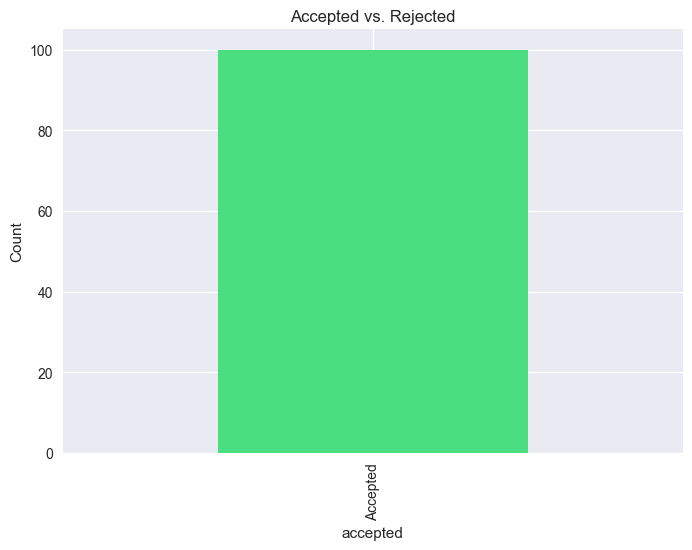

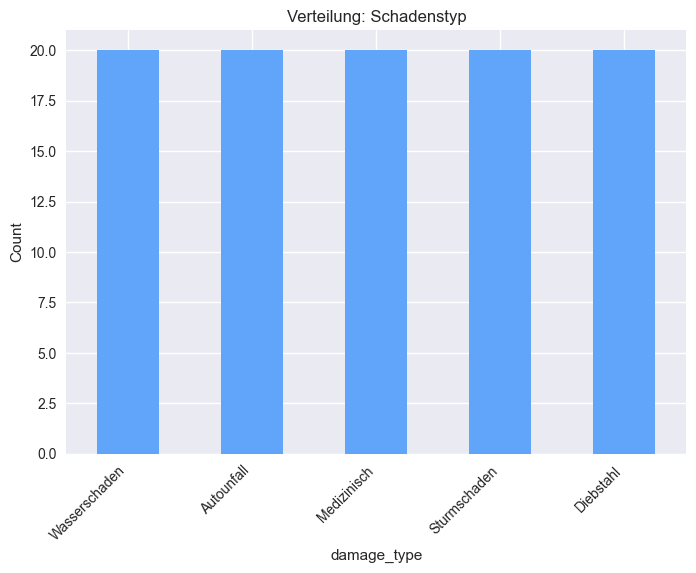

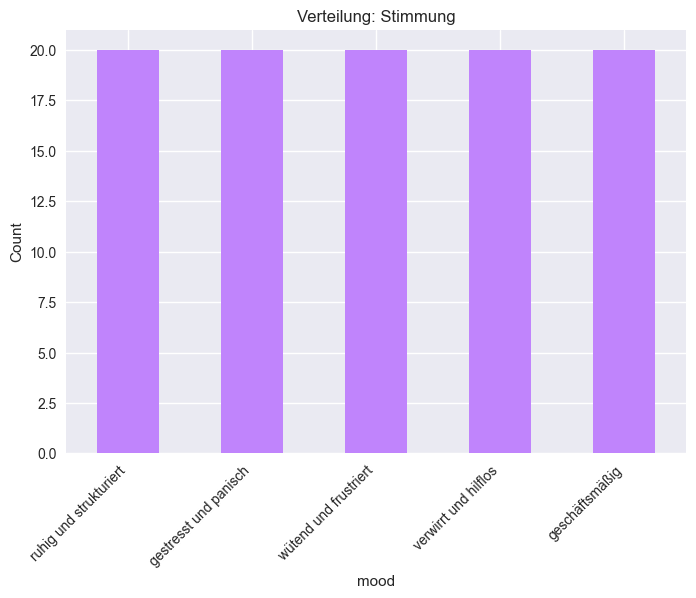

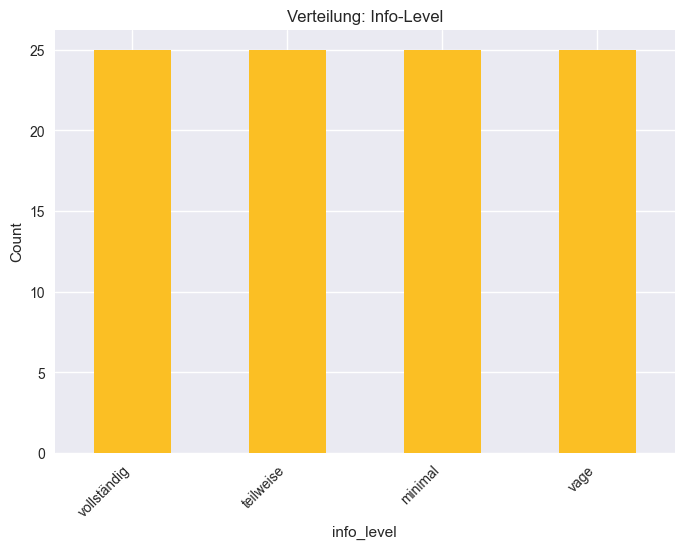

In [43]:
# Accepted vs. Rejected
df["accepted"].value_counts().rename(index={True: "Accepted", False: "Rejected"}).plot.bar(color=["#4ade80", "#f87171"])
plt.title("Accepted vs. Rejected")
plt.ylabel("Count")
plt.show()

# Schadenstyp
df["damage_type"].value_counts().plot.bar(color="#60a5fa")
plt.title("Verteilung: Schadenstyp")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.show()

# Stimmung
df["mood"].value_counts().plot.bar(color="#c084fc")
plt.title("Verteilung: Stimmung")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.show()

# Info-Level
df["info_level"].value_counts().plot.bar(color="#fbbf24")
plt.title("Verteilung: Info-Level")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.show()

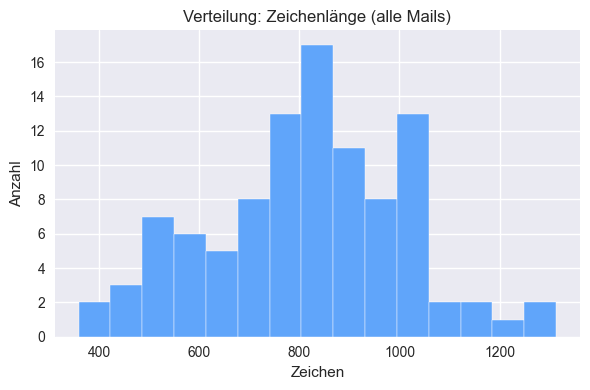

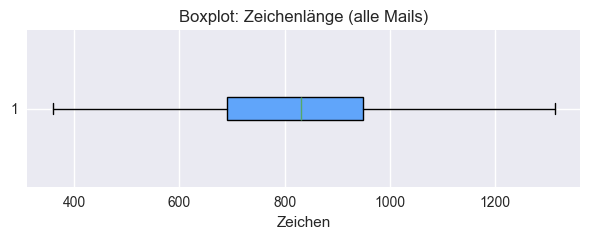

In [44]:
import matplotlib.pyplot as plt

# Histogramm (alle Mails)
plt.figure(figsize=(6,4))
plt.hist(df["char_count"], bins=15, color="#60a5fa", edgecolor="white")
plt.title("Verteilung: Zeichenlänge (alle Mails)")
plt.xlabel("Zeichen")
plt.ylabel("Anzahl")
plt.tight_layout()
plt.show()

# Boxplot (alle Mails)
plt.figure(figsize=(6,2.5))
plt.boxplot(df["char_count"], vert=False, patch_artist=True,
            boxprops=dict(facecolor="#60a5fa"))
plt.title("Boxplot: Zeichenlänge (alle Mails)")
plt.xlabel("Zeichen")
plt.tight_layout()
plt.show()
